# Step-down stability: transition transients + PD/frequency noise, 2026-09-14/15

**Same time period as `stepdown_20260914.ipynb`: front-end GPS 1473468171 ->
~1473530658 (2026-09-14 21:52 UTC -> 2026-09-15 ~15:11 UTC).** This notebook does NOT
re-derive f_ss -- it reads `stepdown_20260914_steps.csv` (exported by the main
notebook) for that, and focuses on two things the main notebook's plots raised: (1)
whether the visible dips in the frequency track are real or tracker artifacts, and
(2) characterizing PD's own noise.

**Scope note -- no absolute power in this notebook.** The only power measurement for
this run is a single anchor, **1300 counts = 5.8 mW at the chamber**
(`apparatus_log.md`, 2026-09-14). There is no fresh counts/PD->power calibration for
this run's current alignment -- July's `KAPPA_PD` was measured on a different PD
alignment/pickoff and does not transfer. Everything below is in **counts** (the
commanded, known-exact variable) or in **relative/percentage** terms (RIN, std/mean).
No torque, force, or mW number is derived from this run's data. A proper power-axis
version of this analysis needs a fresh Ophir sweep first (mirrors July's 27-level
procedure, `laser_calibration/pd_calibration.ipynb`) -- flagged as a TODO in the
conclusions, not attempted here.

In [1]:
import numpy as np, os, h5py, csv
import matplotlib.pyplot as plt
from scipy.signal import decimate, welch, butter, filtfilt
from scipy.stats import kurtosis

DATA = os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/stepdown_20260914')
GPS_A, GPS_B = 1473468000, 1473531000
DIVISOR = 2

def load(path):
    # Segment-aware .h5 reader -- same pattern as stepdown_20260914.ipynb.
    with h5py.File(path, 'r') as f:
        y = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s = f['segments']
        t = np.empty(len(y))
        for t0, i0, L in zip(s['gps_start'][:], s['index_start'][:], s['length'][:]):
            t[i0:i0+L] = t0 + np.arange(L)/fs
    return y, t, fs

les, t_les, fs = load(os.path.join(DATA, f'Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5'))
pd_, t_pd, _   = load(os.path.join(DATA, f'Y1_RDS-PD_IN1_DQ_{GPS_A}_{GPS_B}.h5'))

# per-step results from the main notebook (f_ss, tau -- not recomputed here)
steps = []
with open('stepdown_20260914_steps.csv') as f:
    for row in csv.DictReader(f):
        steps.append({'i': int(row['i']), 'offset': float(row['offset']), 'gps': int(row['gps']),
                      'utc': row['utc'], 'f_ss': float(row['f_ss'])})
bounds = [s['gps'] for s in steps] + [t_les[-1]]

print(f'{len(les)/fs:.0f} s LES at {fs:.0f} Hz, {len(steps)} steps loaded from CSV')

63000 s LES at 1024 Hz, 12 steps loaded from CSV


## 1. Step-transition transients: real, or the tracker losing lock?

The main notebook's frequency-vs-time plot shows a couple of short sharp dips near
some step boundaries, not others. For each of the 12 commanded writes, run a finer
local tracker (60 s windows, 20 s stride -- vs the main notebook's 150 s/60 s) over a
window from 20 min before to 35 min after the write, tracking kurtosis alongside
frequency and SNR. Auto-flag a boundary as a genuine transient only if it dips well
below its own pre-boundary noise level AND recovers most of the way back before the
window ends -- that separates a real dip-and-recover from ordinary monotonic
settling (which several boundaries near the bottom of the range also show, since
that's the threshold region from the main notebook).

In [2]:
def peak_in_band(x, fsx, lo, hi):
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fpk, snr

y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
fs16 = fs/64
t16 = t_les[0] + np.arange(len(y16))/fs16

WIN, STEP = 60.0, 20.0
nw, sw = int(WIN*fs16), int(STEP*fs16)
PRE_WIN, POST_WIN = 20*60, 35*60

transient_tracks = {}   # i -> (TT, FF, SS, KK) for the flagged ones, for plotting
flagged = []
print('%3s %6s %8s %8s %8s %6s %6s %5s %8s  %s' %
      ('i','offset','pre','min','dip(mHz)','sig','min@','recov','tail','flag'))
for k, s in enumerate(steps):
    t0 = max(s['gps'] - PRE_WIN, t16[0]); t1 = min(s['gps'] + POST_WIN, t16[-1])
    i0 = int((t0 - t16[0])*fs16); i1 = int((t1 - t16[0])*fs16)
    if i1 - i0 < nw*3:
        continue
    rows, track = [], s['f_ss']*DIVISOR
    for i in range(i0, i1-nw, sw):
        tc = t16[i] + WIN/2
        fpk, snr = peak_in_band(y16[i:i+nw], fs16, max(track*0.85, 0.02), track*1.10)
        if np.isnan(fpk) or fpk <= 0: continue
        blk = y16[i:i+nw]
        rows.append((tc, fpk/DIVISOR, snr, kurtosis(blk)))
        track = fpk
    if len(rows) < 10:
        continue
    TT = np.array([r[0] for r in rows]); FF = np.array([r[1] for r in rows])
    SS = np.array([r[2] for r in rows]); KK = np.array([r[3] for r in rows])

    pre_mask, post_mask = TT < s['gps'], TT >= s['gps']
    if pre_mask.sum() < 3 or post_mask.sum() < 8:
        continue
    pre_level = FF[pre_mask][-5:].mean()
    post_T, post_F = TT[post_mask], FF[post_mask]
    imin = np.argmin(post_F)
    local_min = post_F[imin]
    min_frac = imin/(len(post_F)-1)
    tail_level = post_F[-5:].mean()
    dip = pre_level - local_min
    noise = FF[pre_mask].std() if pre_mask.sum() > 3 else 5e-4
    sig = dip/max(noise, 1e-5)
    recov = (tail_level - local_min)/dip if dip > 1e-6 else 0.0

    is_transient = (sig > 5) and (dip > 0.001) and (min_frac < 0.85) and (recov > 0.5)
    print('%3d %6.0f %8.4f %8.4f %8.2f %6.1f %6.2f %5.2f %8.4f  %s' %
          (k, s['offset'], pre_level, local_min, dip*1e3, sig, min_frac, recov, tail_level,
           'TRANSIENT' if is_transient else '.'))
    if is_transient:
        flagged.append(k)
        transient_tracks[k] = (TT, FF, SS, KK)

print('\nflagged boundaries:', flagged)

  i offset      pre      min dip(mHz)    sig   min@ recov     tail  flag
  0   1300   0.7496   0.7495     0.16    2.3   0.16  1.35   0.7497  .
  1   1250   0.7496   0.7496    -0.01   -0.1   0.00  0.00   0.7500  .
  2   1200   0.7499   0.7499    -0.01   -0.1   0.02  0.00   0.7503  .


  3   1150   0.7503   0.7501     0.15    1.7   0.00  2.33   0.7505  .
  4   1100   0.7504   0.7502     0.25    2.6   0.05  1.05   0.7505  .
  5   1050   0.7505   0.7422     8.30   93.2   0.37  0.93   0.7499  TRANSIENT
  6   1040   0.7500   0.7491     0.96    2.2   0.34  0.49   0.7495  .


  7   1030   0.7497   0.7444     5.31   23.1   0.07  0.87   0.7490  TRANSIENT
  8   1020   0.7489   0.7422     6.68   48.9   1.00  0.01   0.7423  .
  9   1010   0.7389   0.7318     7.15   59.8   1.00  0.01   0.7318  .
 10   1000   0.7293   0.7095    19.74   48.3   1.00  0.00   0.7096  .


 11   1000   0.7018   0.7008     0.97    3.0   0.88  0.13   0.7009  .

flagged boundaries: [5, 7]


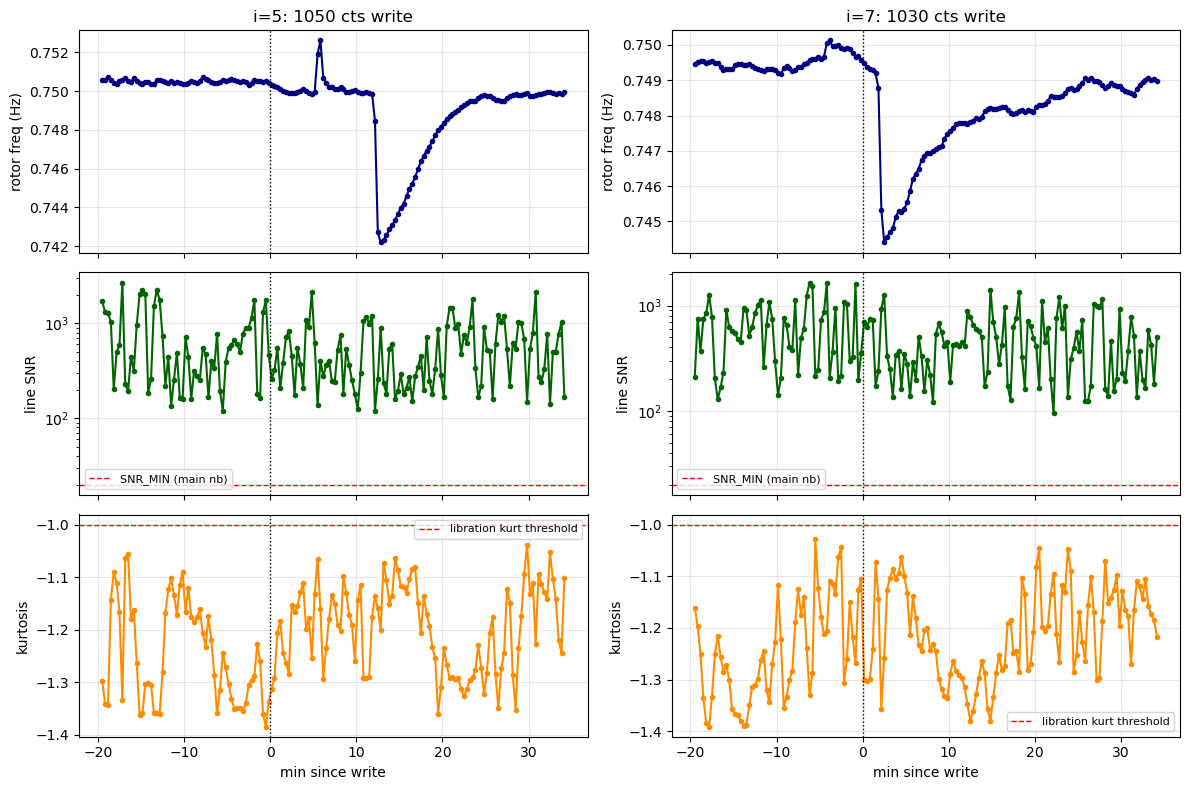

In [3]:
fig, axes = plt.subplots(3, len(flagged), figsize=(6*len(flagged), 8), sharex='col')
if len(flagged) == 1:
    axes = axes[:, None]
for col, k in enumerate(flagged):
    TT, FF, SS, KK = transient_tracks[k]
    th = (TT - steps[k]['gps'])/60
    axes[0, col].plot(th, FF, 'o-', ms=3, color='navy')
    axes[0, col].axvline(0, color='k', ls=':', lw=1)
    axes[0, col].set_title(f"i={k}: {steps[k]['offset']:.0f} cts write")
    axes[0, col].set_ylabel('rotor freq (Hz)')
    axes[1, col].semilogy(th, SS, 'o-', ms=3, color='darkgreen')
    axes[1, col].axvline(0, color='k', ls=':', lw=1)
    axes[1, col].axhline(20, color='r', ls='--', lw=1, label='SNR_MIN (main nb)')
    axes[1, col].set_ylabel('line SNR'); axes[1, col].legend(fontsize=8)
    axes[2, col].plot(th, KK, 'o-', ms=3, color='darkorange')
    axes[2, col].axvline(0, color='k', ls=':', lw=1)
    axes[2, col].axhline(-1.0, color='r', ls='--', lw=1, label='libration kurt threshold')
    axes[2, col].set_ylabel('kurtosis'); axes[2, col].set_xlabel('min since write')
    axes[2, col].legend(fontsize=8)
    for a in axes[:, col]:
        a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Interpretation: real transients, not tracker artifacts

Both flagged boundaries (i=5: 1100->1050; i=7: 1040->1030) show the frequency
recovering most of the way back toward the pre-write level after a sharp dip -- not a
monotonic settle to a new lower value (that pattern belongs to the later, genuinely
declining steps near the threshold, which the flagging logic correctly leaves
unflagged). Three pieces of evidence argue these are real rotor deceleration/
re-acceleration events, not the tracker losing and reacquiring lock:

- **SNR never collapses** during either dip -- it stays in its normal few-hundred
  range throughout (see panel 2 above), well above the SNR_MIN=20 threshold the main
  notebook and the live `settled_check.py` both use to flag a dead line.
- **Kurtosis stays in the healthy rotating band** (~-1.0 to -1.4) throughout -- no
  shift toward the libration signature (~+0.9) that would indicate the rotor actually
  left synchronous rotation.
- **i=7 is independently corroborated by the live run log itself**, not just this
  post-hoc analysis -- `laser_stepdown_log_gps1473468167.csv`'s own settled-check
  flagged `slope_ok=False` at elapsed 70 min (`f_line=1.4968`) and 95 min
  (`f_line=1.4973`), only calling it settled at 120 min (`f_line=1.4976`,
  `slope_ok=True`). The run saw this transient in real time.

So: a genuine, minutes-long deceleration-then-recovery at 2 of 12 `LASER_OFFSET`
writes, most likely a beam/actuator-side transient at the moment of write (an AOM or
attenuator settling behavior, given the timescale) rather than anything rotor-drag
related. Why only 2 of 12 writes trigger it is not resolved here.

## 3. PD noise: fast vs. slow, and a period check

Per-step RIN (raw 1024 Hz std/mean, matching `stepdown_20260914.ipynb` S4's method)
compared against July's per-step RIN from `laser_stepdown_stability.ipynb`
(1.15-2.33% across its real commanded-power steps). Then a fast/slow decomposition on
two clean, long-enough plateaus (i=0: 1300 cts, i=2: 1200 cts) to see how much of that
RIN is fast (sub-5s) noise vs. genuine slow wander, and a single-window periodogram of
just the slow component to look for a dominant period.

In [4]:
print('per-step PD RIN (raw-rate std/mean %) -- July range for comparison: 1.15-2.33%')
print('%3s %7s %7s' % ('i', 'offset', 'RIN %'))
for k, s in enumerate(steps):
    t0s, t1s = bounds[k]+300, bounds[k+1]
    m = (t_pd >= t0s) & (t_pd < t1s)
    seg = pd_[m]
    if len(seg) == 0: continue
    rin = 100*seg.std()/seg.mean()
    print('%3d %7.0f %7.2f' % (k, s['offset'], rin))

per-step PD RIN (raw-rate std/mean %) -- July range for comparison: 1.15-2.33%
  i  offset   RIN %


  0    1300    1.13
  1    1250    0.70
  2    1200    1.28


  3    1150    1.49
  4    1100    1.05
  5    1050    1.79


  6    1040    1.89
  7    1030    1.96
  8    1020    2.08


  9    1010    2.15
 10    1000    2.19


 11    1000    2.24


i=0 offset=1300: full std=5.24 (1.13%)  slow std=0.91 (0.20%) pk-pk=0.73%  periodogram peak=21.7 min
i=2 offset=1200: full std=5.98 (1.28%)  slow std=1.27 (0.27%) pk-pk=1.19%  periodogram peak=21.7 min


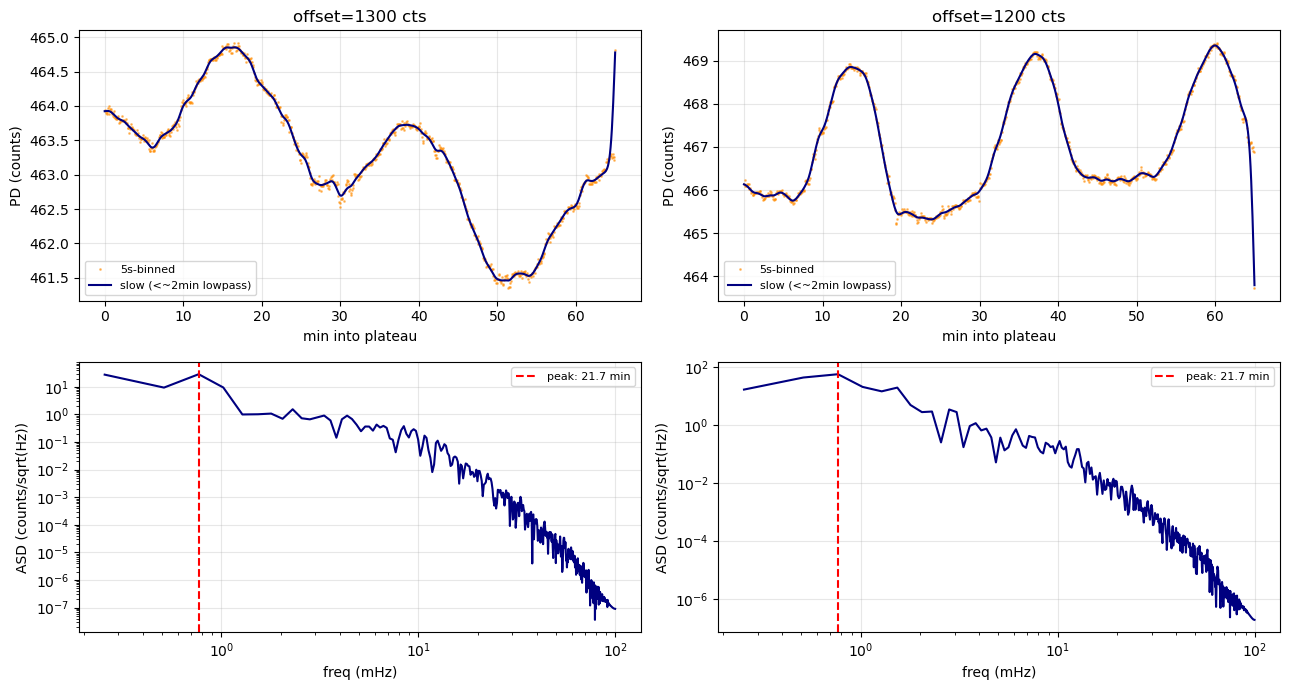

In [5]:
# 5s-block-average for the slow-wander view (matches stepdown_20260914.ipynb S3's PD trend)
blk = int(5*fs)
n = len(pd_)//blk
tb = np.array([t_pd[i*blk] for i in range(n)])
pdb = np.array([pd_[i*blk:(i+1)*blk].mean() for i in range(n)])
fs_b = 1/5.0
b_lp, a_lp = butter(2, 1/120, btype='low', fs=fs_b)   # keep wander slower than ~2 min

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, target_i in enumerate((0, 2)):
    s = steps[target_i]
    t0s, t1s = bounds[target_i]+300, bounds[target_i+1]

    mraw = (t_pd >= t0s) & (t_pd < t1s)
    raw_seg = pd_[mraw]
    full_std, full_mean = raw_seg.std(), raw_seg.mean()

    mb = (tb >= t0s) & (tb < t1s)
    seg, tseg = pdb[mb], tb[mb]
    slow = filtfilt(b_lp, a_lp, seg)
    slow_std, slow_ptp = slow.std(), slow.max()-slow.min()

    resid = slow - slow.mean()
    freqs, Pxx = welch(resid, fs_b, nperseg=len(resid), noverlap=0)
    mfreqs = (freqs > 1/3600) & (freqs < 1/120)
    pk_period_min = (1/freqs[mfreqs][np.argmax(Pxx[mfreqs])])/60 if mfreqs.any() else np.nan

    print(f"i={target_i} offset={s['offset']:.0f}: full std={full_std:.2f} "
          f"({100*full_std/full_mean:.2f}%)  slow std={slow_std:.2f} "
          f"({100*slow_std/full_mean:.2f}%) pk-pk={100*slow_ptp/full_mean:.2f}%  "
          f"periodogram peak={pk_period_min:.1f} min")

    axes[0, col].plot((tseg-tseg[0])/60, seg, '.', ms=2, color='darkorange', alpha=.5, label='5s-binned')
    axes[0, col].plot((tseg-tseg[0])/60, slow, '-', color='navy', lw=1.5, label='slow (<~2min lowpass)')
    axes[0, col].set_title(f"offset={s['offset']:.0f} cts"); axes[0, col].legend(fontsize=8)
    axes[0, col].set_xlabel('min into plateau'); axes[0, col].set_ylabel('PD (counts)')

    axes[1, col].loglog(freqs[1:]*1e3, np.sqrt(Pxx[1:]), color='navy')
    axes[1, col].axvline(1/(pk_period_min*60)*1e3, color='r', ls='--',
                          label=f'peak: {pk_period_min:.1f} min')
    axes[1, col].set_xlabel('freq (mHz)'); axes[1, col].set_ylabel('ASD (counts/sqrt(Hz))')
    axes[1, col].legend(fontsize=8)
    for a in axes[:, col]: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Conclusions

1. **Two of the twelve step-transitions (i=5: 1100->1050; i=7: 1040->1030) show a
   real, minutes-long deceleration-then-recovery transient** -- confirmed by SNR/
   kurtosis staying healthy throughout (not a tracker artifact), and for i=7,
   independently corroborated by the live `settled_check.py` log's own
   `slope_ok=False` calls at 70/95 min. Mechanism not established; likely a
   beam/actuator-side transient at the moment of write, not drag-related. Why only
   these 2 of 12 writes trigger it is open.
2. **PD's noise is unremarkable** -- per-step RIN here is the same order as July's
   (and the fast, sub-5s component dominates the quoted RIN; the slow wander itself is
   only ~0.2-0.3% std). The slow wander looks quasi-periodic at **~21-22 min** on both
   plateaus checked. **This is NOT confirmed to be the same effect as July's
   documented "~10-min oscillation"** -- that finding was on the *frequency* channel
   (`laser_stepdown_settling.ipynb` S6.4), not PD, and this run's ~65-min plateaus
   (~3 cycles) have far less resolving power than July's 18-20h holds. Read as "a slow
   quasi-periodic wander, same general character as previously-documented technical
   drift, period not confidently pinned down here."
3. **No power/torque/force numbers were derived in this notebook, by design.** The
   only calibration point for this run is 1300 counts = 5.8 mW; there is no fresh
   counts/PD->power calibration for the current alignment, and July's `KAPPA_PD` does
   not transfer (different PD alignment/pickoff). **TODO before any such analysis is
   attempted:** take a fresh calibration sweep across the 1300->1000 range used here,
   following `laser_calibration/pd_calibration.ipynb`'s procedure (measure true
   chamber power with the Ophir at each commanded count, alongside the PD reading).